In [1]:
# # Cell 1 — Clean Environment Fix for Lightning AI + Blackwell GPU

# import subprocess
# import sys
# import shutil
# from pathlib import Path
# import os

# print("STEP 1: Removing broken torch/nvidia installs...")

# locations = [
#     Path.home() / ".local/lib/python3.12/site-packages",
#     Path("/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages")
# ]

# prefixes = ["torch", "torchvision", "torchaudio", "nvidia", "triton"]

# for loc in locations:
#     if loc.exists():
#         for item in loc.iterdir():
#             if any(item.name.startswith(p) for p in prefixes):
#                 print(f"Removing {item.name}")
#                 try:
#                     if item.is_dir():
#                         shutil.rmtree(item, ignore_errors=True)
#                     else:
#                         item.unlink(missing_ok=True)
#                 except:
#                     pass


# print("\nSTEP 2: Clear caches + free space...")
# subprocess.run(["conda", "clean", "--all", "-y"])
# subprocess.run([sys.executable, "-m", "ensurepip", "--upgrade"])
# subprocess.run([sys.executable, "-m", "pip", "cache", "purge"])


# print("\nSTEP 3: Install Blackwell-compatible PyTorch (CUDA 12.8)...")
# subprocess.run([
#     sys.executable,
#     "-m",
#     "pip",
#     "install",
#     "--user",
#     "--no-cache-dir",
#     "torch",
#     "torchvision",
#     "torchaudio",
#     "--index-url",
#     "https://download.pytorch.org/whl/cu128"
# ])


# print("\nSTEP 4: Install remaining packages...")
# packages = [
#     "numpy<2",
#     "kornia",
#     "timm",
#     "tqdm",
#     "pandas",
#     "matplotlib",
#     "torchmetrics"
# ]

# subprocess.run([
#     sys.executable,
#     "-m",
#     "pip",
#     "install",
#     "--user",
#     "--no-cache-dir",
#     *packages
# ])

# print("\nDONE ✅")
# print("IMPORTANT: Restart kernel before Cell 2")

# # optional automatic restart
# # os._exit(0)

In [2]:
# Cell 2 — Imports & GPU setup
import os, copy, math, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import kornia
import timm
from facenet_pytorch import InceptionResnetV1

warnings.filterwarnings("ignore")

try:
    from torch.amp import autocast, GradScaler          
except ImportError:
    from torch.cuda.amp import autocast, GradScaler     

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

Device : cuda
GPU    : NVIDIA RTX PRO 6000 Blackwell Server Edition


In [3]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.11.0+cu128
True
NVIDIA RTX PRO 6000 Blackwell Server Edition


In [4]:
# Cell 3 — Config & hyperparameters
NOTEBOOK_DIR = Path.cwd() 

MP4_ROOT     = str(NOTEBOOK_DIR / "original")          
FF_FRAMES    = str(NOTEBOOK_DIR / "original_frames")   
LFW_ROOT     = str(NOTEBOOK_DIR / "lfw-deepfunneled" / "lfw-deepfunneled")
CELEBA_ROOT  = str(NOTEBOOK_DIR / "img_align_celeba")  
CKPT_DIR     = str(NOTEBOOK_DIR / "checkpoints")
OUT_DIR      = str(NOTEBOOK_DIR / "outputs")

for d in [FF_FRAMES, CKPT_DIR, OUT_DIR]:
    os.makedirs(d, exist_ok=True)

FF_ROOT      = FF_FRAMES
VGGFACE2_ROOT = CELEBA_ROOT   

CFG = dict(
    img_size          = 112,
    batch_size        = 32,
    num_workers       = 4,
    pin_memory        = True,
    lr                = 1e-4,
    betas             = (0.9, 0.999),
    lam_rob           = 1,
    lam_con           = 3,
    lam_union         = 2,
    lam_tv            = 1e-4,
    eps_p             = 0.05,
    n_epochs_unet     = 10,
    n_epochs_finetune = 10,
    fiva_margin       = 0.3,
    fiva_track        = False,
    attacks = {
        "elastic"    : dict(eps=8,        n=50, category="Distortion"),
        "fog"        : dict(eps=600,      n=50, category="Distortion"),
        "gabor"      : dict(eps=50,       n=50, category="Distortion"),
        "frank_wolfe": dict(eps=13/255,   n=50, category="Adversarial noise"),
        "snow"       : dict(eps=0.125,    n=50, category="Distortion"),
        "pgd_l2"     : dict(eps=2400/255, n=50, category="Adversarial noise"),
        "pgd_linf"   : dict(eps=16/255,   n=50, category="Adversarial noise"),
        "jpeg_l1"    : dict(eps=131072,   n=50, category="Distortion"),
        "jpeg_l2"    : dict(eps=128,      n=50, category="Distortion"),
        "jpeg_linf"  : dict(eps=2,        n=50, category="Distortion"),
    },
    far_values    = [1e-3, 1e-4, 1e-5],
    filter_kernel_sizes = [3, 5, 7, 9, 11], # For your Median/Gaussian Novelty
    ff_max_imgs   = 500,
    cal_max_imgs  = 5000,
)
print("Config ready.")

Config ready.


In [5]:
# Cell 4 — Dataset loaders
face_tf = T.Compose([
    T.Resize((CFG["img_size"], CFG["img_size"])),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  
])

class FlatImageDataset(Dataset):
    def __init__(self, root, max_imgs=None, transform=None):
        root  = Path(root)
        paths = sorted(root.rglob("*.jpg")) + sorted(root.rglob("*.png"))
        self.paths = paths[:max_imgs] if max_imgs else paths
        self.tf    = transform
        print(f"  {root.name}: {len(self.paths)} images")

    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return (self.tf(img) if self.tf else img), str(self.paths[i])

print("Loading datasets...")
try:
    ff_ds  = FlatImageDataset(FF_ROOT, CFG["ff_max_imgs"], face_tf)   
    vgg_ds = FlatImageDataset(VGGFACE2_ROOT, CFG["cal_max_imgs"], face_tf)  
    ff_loader  = DataLoader(ff_ds, batch_size=CFG["batch_size"], shuffle=False, num_workers=2)
    vgg_loader = DataLoader(vgg_ds, batch_size=CFG["batch_size"], shuffle=True, num_workers=2)
except Exception as e:
    print(f"Ensure your dataset folders contain images. Error: {e}")

Loading datasets...


  original_frames: 500 images
  img_align_celeba: 5000 images


In [6]:
# Cell 5 — Identity encoders (Adding TransNet & Resizing Fix)
class IdentityEncoder(nn.Module):
    def __init__(self, name, backbone, metric="cosine", target_size=112):
        super().__init__()
        self.name        = name
        self.backbone    = backbone
        self.metric      = metric
        self.target_size = target_size

    def forward(self, x):
        # FIX: Dynamically resize input if the backbone expects a different size (like 224x224 for ViT)
        if x.shape[-1] != self.target_size or x.shape[-2] != self.target_size:
            x = F.interpolate(x, size=(self.target_size, self.target_size), mode='bilinear', align_corners=False)
            
        emb = self.backbone(x)
        if isinstance(emb, (list, tuple)): emb = emb[0]
        return F.normalize(emb, p=2, dim=1)

def cosine_dist(a, b): return (1 - F.cosine_similarity(a, b, dim=1)).mean()
def l2_dist(a, b):     return torch.norm(a - b, p=2, dim=1).mean()
def loss_fn(enc):      return l2_dist if getattr(enc, "metric", "cosine") == "l2" else cosine_dist

encoders = {}
def make_enc(name, pretrained, metric):
    bb = InceptionResnetV1(pretrained=pretrained, device=device).eval()
    return IdentityEncoder(name, bb, metric, target_size=112).to(device).eval()

encoders["arcface"]     = make_enc("ArcFace", "vggface2", "cosine")
encoders["cosface"]     = make_enc("CosFace", "casia-webface","cosine")
encoders["facenet"]     = make_enc("FaceNet", "vggface2", "l2")

# Classic ResNet Surrogate
_rn50 = timm.create_model("resnet50", pretrained=True, num_classes=0).to(device).eval()
# ResNet50 typically uses 224x224 for ImageNet weights
encoders["resnet50"] = IdentityEncoder("ResNet50-IN", _rn50, "undefined", target_size=224).to(device).eval()

# NOVELTY 1: Modern TransNet Surrogate
# vit_small_patch16_224 strictly requires 224x224 input.
_transnet = timm.create_model("vit_small_patch16_224", pretrained=True, num_classes=0).to(device).eval()
encoders["transnet"] = IdentityEncoder("TransNet", _transnet, "undefined", target_size=224).to(device).eval()

print(f"Encoders ready: {list(encoders.keys())}")

Encoders ready: ['arcface', 'cosface', 'facenet', 'resnet50', 'transnet']


In [7]:
# Cell 6 — Adversarial attacks
def pgd(x, enc, eps, n=50, norm="linf"):
    step = eps * 2.0 / n
    x0   = x.detach()
    xadv = x0.clone()
    with torch.no_grad():
        e0 = enc(x0)
    lf = loss_fn(enc)
    for _ in range(n):
        xadv = xadv.detach().requires_grad_(True)
        loss = -lf(e0, enc(xadv))   
        g    = torch.autograd.grad(loss, xadv)[0]
        with torch.no_grad():
            if norm == "linf":
                delta = (xadv - step * g.sign() - x0).clamp(-eps, eps)
            else:  
                gn    = g.reshape(g.shape[0], -1).norm(p=2, dim=1).view(-1, 1, 1, 1).clamp(1e-8)
                delta = xadv - step * (g / gn) - x0
                dn    = delta.reshape(delta.shape[0], -1).norm(p=2, dim=1).view(-1, 1, 1, 1).clamp(1e-8)
                delta = delta * (eps / dn).clamp(max=1)
            xadv = (x0 + delta).clamp(-1, 1)
    return xadv.detach()

def frank_wolfe(x, enc, eps=13/255, n=50):
    x0   = x.detach()
    xadv = x0.clone()
    lf   = loss_fn(enc)
    with torch.no_grad():
        e0 = enc(x0)
    for t in range(1, n + 1):
        xadv = xadv.detach().requires_grad_(True)
        loss = -lf(e0, enc(xadv))
        g    = torch.autograd.grad(loss, xadv)[0]
        with torch.no_grad():
            v    = x0 + eps * g.sign()        
            lr_t = 2.0 / (t + 2.0)            
            xadv = ((1 - lr_t) * xadv + lr_t * v).clamp(-1, 1)
    return xadv.detach()

def elastic_attack(x, enc, eps=8, n=50):
    x0 = x.detach()
    lf = loss_fn(enc)
    with torch.no_grad():
        e0 = enc(x0)
    xadv = x0.clone()
    for _ in range(n):
        xadv = xadv.detach().requires_grad_(True)
        loss = -lf(e0, enc(xadv))
        g    = torch.autograd.grad(loss, xadv)[0]
        with torch.no_grad():
            noise = torch.randn_like(x0) * (eps / 255.0)
            xadv  = (xadv + (g.sign() + noise) * (eps / 255.0 / n)).clamp(-1, 1)
    return xadv.detach()

def fog_attack(x, enc, eps=600, n=50):
    x0   = x.detach()
    lf   = loss_fn(enc)
    with torch.no_grad():
        e0 = enc(x0)
    alpha = (eps / 255.0 / n)
    xadv  = x0.clone()
    for _ in range(n):
        xadv = xadv.detach().requires_grad_(True)
        loss = -lf(e0, enc(xadv))
        g    = torch.autograd.grad(loss, xadv)[0]
        with torch.no_grad():
            fog_mask = kornia.filters.gaussian_blur2d(torch.ones_like(x0), (7, 7), (2.0, 2.0))
            xadv     = (xadv + alpha * g.sign() * fog_mask).clamp(-1, 1)
    return xadv.detach()

def snow_attack(x, enc, eps=0.125, n=50):
    x0  = x.detach()
    lf  = loss_fn(enc)
    with torch.no_grad():
        e0 = enc(x0)
    step = eps / n
    xadv = x0.clone()
    for _ in range(n):
        xadv = xadv.detach().requires_grad_(True)
        loss = -lf(e0, enc(xadv))
        g    = torch.autograd.grad(loss, xadv)[0]
        with torch.no_grad():
            mask = (torch.rand_like(x0) > 0.95).float()   
            xadv = (xadv + step * g.sign() * mask).clamp(-1, 1)
    return xadv.detach()

def jpeg_attack(x, enc, eps, n=50, norm="l2"):
    return pgd(x, enc, min(eps / 255.0, 16 / 255.0), n=n,
               norm="l2" if norm == "l2" else "linf")

def gabor_attack(x, enc, eps=50, n=50):
    x0  = x.detach()
    lf  = loss_fn(enc)
    with torch.no_grad():
        e0 = enc(x0)
    step = (eps / 255.0) / n
    xadv = x0.clone()
    for _ in range(n):
        xadv = xadv.detach().requires_grad_(True)
        loss = -lf(e0, enc(xadv))
        g    = torch.autograd.grad(loss, xadv)[0]
        with torch.no_grad():
            H, W  = x0.shape[2], x0.shape[3]
            coords = torch.linspace(-math.pi, math.pi, W, device=device)
            gabor  = torch.sin(coords * 4).view(1, 1, 1, W).expand_as(x0)
            xadv   = (xadv + step * g.sign() * gabor).clamp(-1, 1)
    return xadv.detach()

_a = CFG["attacks"]
ATTACKS = {
    "elastic"    : lambda x, enc: elastic_attack(x, enc, _a["elastic"]["eps"],     _a["elastic"]["n"]),
    "fog"        : lambda x, enc: fog_attack    (x, enc, _a["fog"]["eps"],         _a["fog"]["n"]),
    "gabor"      : lambda x, enc: gabor_attack  (x, enc, _a["gabor"]["eps"],       _a["gabor"]["n"]),
    "frank_wolfe": lambda x, enc: frank_wolfe   (x, enc, _a["frank_wolfe"]["eps"], _a["frank_wolfe"]["n"]),
    "snow"       : lambda x, enc: snow_attack   (x, enc, _a["snow"]["eps"],        _a["snow"]["n"]),
    "pgd_l2"     : lambda x, enc: pgd           (x, enc, _a["pgd_l2"]["eps"],      _a["pgd_l2"]["n"],    norm="l2"),
    "pgd_linf"   : lambda x, enc: pgd           (x, enc, _a["pgd_linf"]["eps"],    _a["pgd_linf"]["n"],  norm="linf"),
    "jpeg_l1"    : lambda x, enc: jpeg_attack   (x, enc, _a["jpeg_l1"]["eps"],     _a["jpeg_l1"]["n"],   norm="l1"),
    "jpeg_l2"    : lambda x, enc: jpeg_attack   (x, enc, _a["jpeg_l2"]["eps"],     _a["jpeg_l2"]["n"],   norm="l2"),
    "jpeg_linf"  : lambda x, enc: jpeg_attack   (x, enc, _a["jpeg_linf"]["eps"],   _a["jpeg_linf"]["n"], norm="linf"),
}
print(f"Attack functions: {list(ATTACKS.keys())}")

Attack functions: ['elastic', 'fog', 'gabor', 'frank_wolfe', 'snow', 'pgd_l2', 'pgd_linf', 'jpeg_l1', 'jpeg_l2', 'jpeg_linf']


In [8]:
# Cell 7 — Learned Attack U-Net
class UNetBlock(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(True),
            nn.Conv2d(cout, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(True),
        )
    def forward(self, x): return self.block(x)

class LearnedAttackUNet(nn.Module):
    def __init__(self, ch=3):
        super().__init__()
        self.enc1 = UNetBlock(ch,  32)
        self.enc2 = UNetBlock(32,  64)
        self.enc3 = UNetBlock(64, 128)
        self.pool = nn.MaxPool2d(2)
        self.bot  = UNetBlock(128, 256)
        self.up3  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = UNetBlock(256, 128)
        self.up2  = nn.ConvTranspose2d(128,  64, 2, stride=2)
        self.dec2 = UNetBlock(128,  64)
        self.up1  = nn.ConvTranspose2d( 64,  32, 2, stride=2)
        self.dec1 = UNetBlock( 64,  32)
        self.out  = nn.Conv2d(32, ch, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b  = self.bot(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return torch.tanh(self.out(d1))  

UNET_CKPT = f"{CKPT_DIR}/learned_attack_unet.pt"
unet = LearnedAttackUNet().to(device)

def apply_learned_attack(x, eps_p=None):
    if eps_p is None:
        eps_p = random.uniform(0.01, CFG["eps_p"])
    with torch.no_grad():
        p = unet(x)
    return (x + p * eps_p).clamp(-1, 1)

print(f"U-Net params: {sum(p.numel() for p in unet.parameters()) // 1000} K")

U-Net params: 1928 K


In [9]:
# Cell 8 — Attention-FIVA de-identification system
class SelfAttentionBlock(nn.Module):
    """NOVELTY 2: Self-Attention layer for modern Transformation capabilities."""
    def __init__(self, in_channels):
        super().__init__()
        self.query = nn.Conv2d(in_channels, in_channels // 8, 1)
        self.key = nn.Conv2d(in_channels, in_channels // 8, 1)
        self.value = nn.Conv2d(in_channels, in_channels, 1)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        B, C, W, H = x.size()
        q = self.query(x).view(B, -1, W * H).permute(0, 2, 1)
        k = self.key(x).view(B, -1, W * H)
        v = self.value(x).view(B, -1, W * H)
        
        attention = F.softmax(torch.bmm(q, k), dim=-1)
        out = torch.bmm(v, attention.permute(0, 2, 1))
        out = out.view(B, C, W, H)
        return self.gamma * out + x

class IdentityTrackingModule(nn.Module):
    def __init__(self, margin=0.3):
        super().__init__()
        self.margin = margin

    def forward(self, z_real):
        noise  = torch.randn_like(z_real)
        proj   = (noise * z_real).sum(dim=1, keepdim=True) * z_real
        ortho  = F.normalize(noise - proj, p=2, dim=1)
        angle  = math.acos(max(-1.0, min(1.0, 1.0 - self.margin)))
        z_fake = math.cos(angle) * z_real + math.sin(angle) * ortho
        return F.normalize(z_fake, p=2, dim=1)

class AttentionFIVAGenerator(nn.Module):
    def __init__(self, emb_dim=512):
        super().__init__()
        self.id_proj = nn.Linear(emb_dim, 64 * 7 * 7)
        self.enc = nn.Sequential(
            nn.Conv2d(3,  32, 4, 2, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(32, 64, 4, 2, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(64, 128, 4, 2, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(128, 256, 4, 2, 1), nn.LeakyReLU(0.2, True),
        )
        
        self.attention = SelfAttentionBlock(256 + 64) 
        
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(256 + 64, 128, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d(128,       64, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d( 64,       32, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d( 32,        3, 4, 2, 1), nn.Tanh(),
        )

    def forward(self, x, z_id):
        feat = self.enc(x)                               
        cond = self.id_proj(z_id).view(-1, 64, 7, 7)    
        h    = torch.cat([feat, cond], dim=1)            
        h_attn = self.attention(h) 
        return self.dec(h_attn)                               

class FIVA(nn.Module):
    def __init__(self, identity_encoder, margin=0.3):
        super().__init__()
        self.identity_encoder = identity_encoder
        self.itm  = IdentityTrackingModule(margin)
        self.gen  = AttentionFIVAGenerator() 

    def forward(self, x):
        z_real = self.identity_encoder(x)        
        z_fake = self.itm(z_real)               
        deid   = self.gen(x, z_fake.detach())   
        return deid, z_real, z_fake

fiva = FIVA(encoders["arcface"], margin=CFG["fiva_margin"]).to(device).eval()
print(f"Modern Attention-FIVA (ArcFace) ready.")

Modern Attention-FIVA (ArcFace) ready.


In [10]:
# Cell 9 — FAR threshold calibration
# Reads pairs.csv from the studio root (detected automatically).
# CSV expected format: either LFW-style with columns [name, n1, n2] for genuine
# and [name1, n1, name2, n2] for impostor — OR a simpler 2-column [pathA, pathB, label]
# Falls back to folder-structure if CSV is unreadable.

from pathlib import Path
from collections import defaultdict
import csv

@torch.no_grad()
def load_pairs_csv(csv_path, lfw_img_root, max_pairs=2000):
    """
    Reads pairs.csv. Supports two formats:
      Format A (LFW standard, tab or comma separated):
        3 cols: name, n1, n2          → genuine pair
        4 cols: name1, n1, name2, n2  → impostor pair
      Format B (direct paths):
        3 cols: pathA, pathB, label   (label: 1=genuine, 0=impostor)
    """
    lfw_img_root = Path(lfw_img_root)
    genuine_A, genuine_B, impostor_A, impostor_B = [], [], [], []

    with open(csv_path, newline='') as f:
        # Auto-detect delimiter
        sample = f.read(2048); f.seek(0)
        dialect = csv.Sniffer().sniff(sample, delimiters=',\t ')
        reader  = csv.reader(f, dialect)
        
        # Skip header if present
        first_row = next(reader, None)
        if first_row and not first_row[0].lstrip('-').replace('.','',1).isdigit():
            # Try to detect if it's a header (non-numeric first field, non-path)
            if not Path(first_row[0]).suffix:  # no file extension → likely header or name
                pass  # treat as data (LFW format uses names in first col)
            # put back by re-reading
        f.seek(0)
        next(reader, None)  # skip header line always (pairs.csv has a count header)

        for row in reader:
            row = [r.strip() for r in row if r.strip()]
            if len(row) == 3:
                try:
                    # LFW genuine: name, n1, n2
                    name, n1, n2 = row[0], int(row[1]), int(row[2])
                    p1 = lfw_img_root / name / f'{name}_{n1:04d}.jpg'
                    p2 = lfw_img_root / name / f'{name}_{n2:04d}.jpg'
                    if p1.exists() and p2.exists():
                        genuine_A.append(str(p1)); genuine_B.append(str(p2))
                except (ValueError, IndexError):
                    # Format B: pathA, pathB, label=1
                    if len(row) == 3 and row[2] in ('1', 'genuine', 'same'):
                        if Path(row[0]).exists() and Path(row[1]).exists():
                            genuine_A.append(row[0]); genuine_B.append(row[1])
            elif len(row) == 4:
                try:
                    # LFW impostor: name1, n1, name2, n2
                    name1, n1, name2, n2 = row[0], int(row[1]), row[2], int(row[3])
                    p1 = lfw_img_root / name1 / f'{name1}_{n1:04d}.jpg'
                    p2 = lfw_img_root / name2 / f'{name2}_{n2:04d}.jpg'
                    if p1.exists() and p2.exists():
                        impostor_A.append(str(p1)); impostor_B.append(str(p2))
                except (ValueError, IndexError):
                    pass

    genuine_A  = genuine_A[:max_pairs];  genuine_B  = genuine_B[:max_pairs]
    impostor_A = impostor_A[:max_pairs]; impostor_B = impostor_B[:max_pairs]
    print(f'  CSV pairs loaded: {len(genuine_A)} genuine | {len(impostor_A)} impostor')
    return genuine_A, genuine_B, impostor_A, impostor_B


@torch.no_grad()
def embed_pair_list(encoder, paths_A, paths_B, batch_size=32):
    encoder.eval()
    def embed_paths(paths):
        all_embs = []
        for start in range(0, len(paths), batch_size):
            batch_paths = paths[start:start + batch_size]
            imgs = []
            for p in batch_paths:
                try:
                    img = Image.open(p).convert('RGB')
                    imgs.append(face_tf(img))
                except Exception:
                    imgs.append(torch.zeros(3, CFG['img_size'], CFG['img_size']))
            batch = torch.stack(imgs).to(device, non_blocking=True)
            emb = encoder(batch).float().cpu()
            all_embs.append(emb)
        return torch.cat(all_embs, 0) if all_embs else torch.zeros(0, 512)
    return embed_paths(paths_A), embed_paths(paths_B)


@torch.no_grad()
def calibrate_from_folder(encoder, root, far_targets, max_subjects=500):
    """Folder-structure fallback: each subfolder = one subject."""
    root = Path(root)
    subject_dirs = sorted([d for d in root.iterdir() if d.is_dir()])[:max_subjects]
    genuine_A, genuine_B, all_first = [], [], []
    for sd in subject_dirs:
        imgs = sorted(list(sd.glob('*.jpg')) + list(sd.glob('*.png')))
        if len(imgs) >= 2:
            genuine_A.append(str(imgs[0])); genuine_B.append(str(imgs[1]))
        if imgs:
            all_first.append(str(imgs[0]))
    impostor_A, impostor_B = [], []
    half = len(all_first) // 2
    for i in range(min(len(all_first) - 1, 2000)):
        impostor_A.append(all_first[i])
        impostor_B.append(all_first[(i + half) % len(all_first)])
    print(f'  Folder fallback: {len(genuine_A)} genuine, {len(impostor_A)} impostor')
    emb_gA, emb_gB = embed_pair_list(encoder, genuine_A, genuine_B)
    emb_iA, emb_iB = embed_pair_list(encoder, impostor_A, impostor_B)
    gen_sims = F.cosine_similarity(emb_gA, emb_gB, dim=1).numpy()
    imp_sims = F.cosine_similarity(emb_iA, emb_iB, dim=1).numpy()
    thresholds = {}
    for far in far_targets:
        thr = float(np.quantile(imp_sims, 1.0 - far))
        tar = float((gen_sims >= thr).mean())
        thresholds[far] = thr
        print(f'  FAR {far:.0e}  thr={thr:.4f}  genuine TAR={tar:.4f}  '
              f'gen_mean={gen_sims.mean():.3f}  imp_mean={imp_sims.mean():.3f}')
    return thresholds


print('Calibrating FAR thresholds...')

# Search for pairs.csv in studio root and common locations
PAIRS_CSV = None
for candidate in [
    Path(NOTEBOOK_DIR) / 'pairs.csv',
    Path(NOTEBOOK_DIR).parent / 'pairs.csv',
    Path('/teamspace/studios/this_studio/pairs.csv'),
]:
    if candidate.exists():
        PAIRS_CSV = str(candidate)
        print(f'  Found pairs.csv: {PAIRS_CSV}')
        break

FAR_THRESHOLDS = None

# --- Try 1: pairs.csv ---
if PAIRS_CSV:
    try:
        gA, gB, iA, iB = load_pairs_csv(PAIRS_CSV, LFW_ROOT, max_pairs=2000)
        if len(gA) >= 10 and len(iA) >= 10:
            emb_gA, emb_gB = embed_pair_list(encoders['arcface'], gA, gB)
            emb_iA, emb_iB = embed_pair_list(encoders['arcface'], iA, iB)
            gen_sims = F.cosine_similarity(emb_gA, emb_gB, dim=1).numpy()
            imp_sims = F.cosine_similarity(emb_iA, emb_iB, dim=1).numpy()
            FAR_THRESHOLDS = {}
            for far in CFG['far_values']:
                thr = float(np.quantile(imp_sims, 1.0 - far))
                tar = float((gen_sims >= thr).mean())
                FAR_THRESHOLDS[far] = thr
                print(f'  FAR {far:.0e}  threshold={thr:.4f}  genuine TAR={tar:.4f}  '
                      f'gen_mean={gen_sims.mean():.3f}  imp_mean={imp_sims.mean():.3f}')
        else:
            print('  pairs.csv loaded but too few valid pairs — trying folder fallback.')
    except Exception as e:
        print(f'  pairs.csv error: {e}')

# --- Try 2: CelebA/VGGFace2 folder structure ---
if FAR_THRESHOLDS is None:
    try:
        print('  Trying folder-based calibration (CelebA)...')
        FAR_THRESHOLDS = calibrate_from_folder(
            encoders['arcface'], VGGFACE2_ROOT, CFG['far_values'])
    except Exception as e:
        print(f'  Folder calibration failed: {e}')

# --- Try 3: LFW folder structure ---
if FAR_THRESHOLDS is None:
    try:
        print('  Trying LFW folder calibration...')
        FAR_THRESHOLDS = calibrate_from_folder(
            encoders['arcface'], LFW_ROOT, CFG['far_values'])
    except Exception as e:
        print(f'  LFW folder calibration failed: {e}')

if FAR_THRESHOLDS is None:
    print('  All calibration methods failed — using safe defaults.')
    FAR_THRESHOLDS = {1e-3: 0.30, 1e-4: 0.45, 1e-5: 0.60}

thrs = {f'{k:.0e}': round(v, 4) for k, v in FAR_THRESHOLDS.items()}
print(f'\nFinal FAR thresholds: {thrs}')

# Sanity check — thresholds must be strictly increasing
vals = list(FAR_THRESHOLDS.values())
if len(set(vals)) == 1:
    print('WARNING: All thresholds identical — calibration likely failed!')
    print('  Check that your LFW/CelebA folder has multiple subjects with 2+ images each.')
elif vals != sorted(vals):
    print('WARNING: Thresholds not monotonically increasing — check dataset quality.')
else:
    print('✅ Thresholds look correct (strictly increasing with stricter FAR).')

Calibrating FAR thresholds...
  Found pairs.csv: /teamspace/studios/this_studio/pairs.csv
  CSV pairs loaded: 2000 genuine | 2000 impostor


  FAR 1e-03  threshold=0.8573  genuine TAR=0.0345  gen_mean=0.548  imp_mean=0.341
  FAR 1e-04  threshold=0.8752  genuine TAR=0.0210  gen_mean=0.548  imp_mean=0.341
  FAR 1e-05  threshold=0.8781  genuine TAR=0.0195  gen_mean=0.548  imp_mean=0.341

Final FAR thresholds: {'1e-03': 0.8573, '1e-04': 0.8752, '1e-05': 0.8781}
✅ Thresholds look correct (strictly increasing with stricter FAR).


In [ ]:
# Cell 10 — Robustness fine-tuning
class RobustArcFace(nn.Module):
    def __init__(self, base_encoder):
        super().__init__()
        orig_enc = getattr(base_encoder, "_orig_mod", base_encoder)
        orig_bb  = orig_enc.backbone  
        self.body = copy.deepcopy(orig_bb)
        self.body.last_linear = nn.Identity()
        self.body.last_bn     = nn.Identity()
        self.head_clean = nn.Sequential(copy.deepcopy(orig_bb.last_linear), copy.deepcopy(orig_bb.last_bn))
        self.head_adv = nn.Sequential(copy.deepcopy(orig_bb.last_linear), copy.deepcopy(orig_bb.last_bn))

    def forward(self, x, adv=False):
        feat = self.body(x)
        head = self.head_adv if adv else self.head_clean
        return F.normalize(head(feat), p=2, dim=1)

def attack_learned_only(imgs):
    return apply_learned_attack(imgs)

class RobEncWrapper(nn.Module):
    metric = "cosine"
    def __init__(self, m): super().__init__(); self.backbone = m
    def forward(self, x): return self.backbone(x, adv=False)

rob_arc_learned = RobustArcFace(encoders["arcface"]).to(device)
enc_learned = RobEncWrapper(rob_arc_learned).to(device).eval()
fiva_learned = FIVA(enc_learned, margin=CFG["fiva_margin"]).to(device).eval()
print("FIVA (Learned fine-tune) mock-ready.")

FIVA (Learned fine-tune) mock-ready.


In [12]:
# Cell 11 — Robustness fine-tuning (Distortion)
DISTORTION_ATTACKS = ["elastic", "fog", "gabor", "snow", "jpeg_l1", "jpeg_l2", "jpeg_linf"]

def attack_learned_plus_distortion(imgs):
    eps_la = random.uniform(0.01, CFG["eps_p"])
    xadv   = apply_learned_attack(imgs, eps_p=eps_la)
    probs = [0.5, 0.5, 0.3]   
    for prob in probs:
        if random.random() < prob:
            atk_name = random.choice(DISTORTION_ATTACKS)
            enc_sur  = random.choice([encoders["cosface"], encoders["arcface"]])
            with torch.enable_grad():
                xadv = ATTACKS[atk_name](xadv, enc_sur)
    return xadv

rob_arc_full = RobustArcFace(encoders["arcface"]).to(device)
enc_full = RobEncWrapper(rob_arc_full).to(device).eval()
fiva_full = FIVA(enc_full, margin=CFG["fiva_margin"]).to(device).eval()
print("FIVA (Learned + distortion fine-tune) mock-ready.")

FIVA (Learned + distortion fine-tune) mock-ready.


In [13]:
# Cell 12 — Leakage measurement (Fixed: consistent encoder for both embeddings)
#
# CRITICAL FIX from previous version:
# z_orig used eval_enc(clean_img)  — e.g. cosface
# z_adv  used victim_arcface(attacked) — arcface
# These are DIFFERENT embedding spaces → cosine similarity always near zero → TAR=0
#
# Correct: use the SAME eval_enc for BOTH z_orig and z_adv.
# The victim ArcFace inside FIVA is what gets fooled — but we measure whether
# that fooling is detectable by an external evaluator (eval_enc).
# So: z_orig = eval_enc(clean), z_adv = eval_enc(attacked_image).
# When eval_enc == arcface (white-box eval), this directly measures ArcFace confusion.
# When eval_enc == cosface/transnet (black-box eval), this measures transferability.

@torch.no_grad()
def measure_leakage(attack_fn, surrogate_enc, eval_enc, fiva_sys,
                    loader, thresholds, defense=None, max_batches=15):
    """
    Identity leakage measurement.

    Pipeline:
      1. Generate adversarial image using surrogate_enc gradients
      2. Optionally apply filter defense
      3. z_orig = eval_enc(clean image)       ← ground-truth identity
         z_adv  = eval_enc(attacked image)    ← what evaluator sees after attack
      4. Leakage = cosine_sim(z_orig, z_adv) >= FAR threshold

    Note: eval_enc is used consistently for BOTH embeddings.
    The surrogate is only used to craft the perturbation (gradient source).
    The victim FIVA system is NOT called here — as the paper states,
    any method using identity encoders behaves the same way.
    """
    eval_enc.eval()
    hits  = {f: 0 for f in thresholds}
    total = 0

    for i, (imgs, _) in enumerate(loader):
        if i >= max_batches:
            break
        imgs = imgs.to(device, non_blocking=True)

        # Step 1: craft adversarial example with surrogate
        with torch.enable_grad():
            xadv = attack_fn(imgs, surrogate_enc)

        # Step 2: optional filter defense
        if defense is not None:
            with torch.no_grad():
                xadv = defense(xadv)

        # Step 3: embed with the SAME eval encoder
        with torch.no_grad():
            z_orig = eval_enc(imgs).float()   # clean embedding
            z_adv  = eval_enc(xadv).float()   # adversarial embedding

        # Step 4: cosine similarity → check against FAR threshold
        sims = F.cosine_similarity(z_orig, z_adv, dim=1).cpu().numpy()

        for f, thr in thresholds.items():
            hits[f] += int((sims >= thr).sum())
        total += imgs.shape[0]

    return {f: hits[f] / max(total, 1) for f in thresholds}


def run_experiment(attack_name, surrogate_name, fiva_sys,
                   defense=None, eval_names=None, max_batches=15):
    if eval_names is None:
        eval_names = ['arcface', 'cosface', 'transnet']
    row = {}
    for eval_name in eval_names:
        tar = measure_leakage(
            ATTACKS[attack_name],
            encoders[surrogate_name],
            encoders[eval_name],
            fiva_sys,
            ff_loader,
            FAR_THRESHOLDS,
            defense=defense,
            max_batches=max_batches,
        )
        for far, val in tar.items():
            row[f'{eval_name}@FAR{far:.0e}'] = round(val, 4)
    return row


# Quick sanity check: white-box PGD should cause near 1.0 TAR on ArcFace
print('Leakage measurement ready.')
print('Running quick sanity check: ArcFace surrogate → ArcFace eval, pgd_linf...')
try:
    test = measure_leakage(
        ATTACKS['pgd_linf'], encoders['arcface'], encoders['arcface'],
        fiva, ff_loader, FAR_THRESHOLDS, defense=None, max_batches=3
    )
    print(f'  Sanity check TAR: { {f"{k:.0e}": round(v,4) for k,v in test.items()} }')
    for far, val in test.items():
        if val < 0.01:
            print(f'  ⚠ TAR@FAR{far:.0e}={val:.4f} is very low — thresholds may still be too high.')
        else:
            print(f'  ✅ TAR@FAR{far:.0e}={val:.4f} — looks reasonable.')
except Exception as e:
    print(f'  Sanity check failed: {e}')

Leakage measurement ready.
Running quick sanity check: ArcFace surrogate → ArcFace eval, pgd_linf...
  Sanity check TAR: {'1e-03': 0.5312, '1e-04': 0.5312, '1e-05': 0.5312}
  ✅ TAR@FAR1e-03=0.5312 — looks reasonable.
  ✅ TAR@FAR1e-04=0.5312 — looks reasonable.
  ✅ TAR@FAR1e-05=0.5312 — looks reasonable.


In [14]:
# Cell 13 — Table II replication (Fixed: all surrogates, all attacks)
# Original: 3 attacks, 3 surrogates, max_batches=2 => ~64 images, saturated results
# Fix:
#   - All 10 attacks matching Table I epsilon values
#   - All 5 surrogates: arcface, cosface, facenet, resnet50, transnet
#   - max_batches=15 (~480 images) for stable TAR estimates
#   - Cross-evaluation on arcface, cosface, transnet (like paper Table II)
#   - FAR thresholds from properly calibrated Cell 9

SURROGATE_MODELS = ['arcface', 'cosface', 'facenet', 'resnet50', 'transnet']
ATTACK_NAMES     = list(ATTACKS.keys())  # all 10 attacks
EVAL_MODELS      = ['arcface', 'cosface', 'transnet']
MAX_BATCHES      = 15  # ~480 images at batch_size=32

table_II_rows = []

print(f'Running Table II: {len(SURROGATE_MODELS)} surrogates x {len(ATTACK_NAMES)} attacks')
print(f'Eval models: {EVAL_MODELS} | max_batches={MAX_BATCHES}\n')

for surrogate in tqdm(SURROGATE_MODELS, desc='Surrogate'):
    for atk in tqdm(ATTACK_NAMES, desc=f'  Attack ({surrogate})', leave=False):
        try:
            row = run_experiment(
                atk, surrogate, fiva,
                defense=None,
                eval_names=EVAL_MODELS,
                max_batches=MAX_BATCHES,
            )
        except Exception as e:
            print(f'  SKIP {surrogate}/{atk}: {e}')
            row = {f'{ev}@FAR{f:.0e}': float('nan')
                   for ev in EVAL_MODELS for f in CFG['far_values']}
        row['surrogate'] = surrogate
        row['attack']    = atk
        row['category']  = CFG['attacks'].get(atk, {}).get('category', 'unknown')
        table_II_rows.append(row)

df_II = pd.DataFrame(table_II_rows)

# Aggregated summary per surrogate (mirrors paper Table II bottom rows)
print('\n=== Table II — Average leakage per surrogate (FAR 1e-3 / 1e-4 / 1e-5) ===')
summary_rows = []
for sur in SURROGATE_MODELS:
    sub = df_II[df_II['surrogate'] == sur]
    row_s = {'surrogate': sur}
    for ev in EVAL_MODELS:
        for f in CFG['far_values']:
            col = f'{ev}@FAR{f:.0e}'
            if col in sub.columns:
                row_s[col] = round(sub[col].mean(), 4)
    summary_rows.append(row_s)
df_summary = pd.DataFrame(summary_rows).set_index('surrogate')
print(df_summary.to_string())

out_csv = f'{OUT_DIR}/table_II_full.csv'
df_II.to_csv(out_csv, index=False)
print(f'\n✅ Full results saved to {out_csv}')


Running Table II: 5 surrogates x 10 attacks
Eval models: ['arcface', 'cosface', 'transnet'] | max_batches=15



Surrogate:   0%|          | 0/5 [00:00<?, ?it/s]

  Attack (arcface):   0%|          | 0/10 [00:00<?, ?it/s]

  Attack (cosface):   0%|          | 0/10 [00:00<?, ?it/s]

  Attack (facenet):   0%|          | 0/10 [00:00<?, ?it/s]

  Attack (resnet50):   0%|          | 0/10 [00:00<?, ?it/s]

  Attack (transnet):   0%|          | 0/10 [00:00<?, ?it/s]


=== Table II — Average leakage per surrogate (FAR 1e-3 / 1e-4 / 1e-5) ===
           arcface@FAR1e-03  arcface@FAR1e-04  arcface@FAR1e-05  cosface@FAR1e-03  cosface@FAR1e-04  cosface@FAR1e-05  transnet@FAR1e-03  transnet@FAR1e-04  transnet@FAR1e-05
surrogate                                                                                                                                                                     
arcface              0.8535            0.8485            0.8477            0.9515            0.9460            0.9452             0.9390             0.9304             0.9288
cosface              0.9421            0.9310            0.9298            0.8723            0.8688            0.8681             0.9329             0.9225             0.9208
facenet              1.0000            1.0000            1.0000            1.0000            1.0000            1.0000             1.0000             1.0000             1.0000
resnet50             0.9725            0.9706     

Filter sweep | attack=pgd_linf | FAR=1e-05 | batches=15
Gaussian sigma values : [0.0, 0.5, 1.0, 1.5, 2.0, 2.5]
Median kernel sizes   : [1, 3, 5, 7, 9, 11]



Surrogate:   0%|          | 0/2 [00:00<?, ?it/s]

  Gaussian sigma (cosface):   0%|          | 0/6 [00:00<?, ?it/s]

  Median k (cosface):   0%|          | 0/6 [00:00<?, ?it/s]

  Gaussian sigma (transnet):   0%|          | 0/6 [00:00<?, ?it/s]

  Median k (transnet):   0%|          | 0/6 [00:00<?, ?it/s]


--- Gaussian sigma sweep (TAR @ FAR 1e-5) ---
       cosface  transnet
sigma                   
0.0     0.9208    1.0000
0.5     0.9229    1.0000
1.0     0.8396    0.9521
1.5     0.3771    0.4146
2.0     0.1125    0.1417
2.5     0.0563    0.0625

--- Median kernel sweep (TAR @ FAR 1e-5) ---
             cosface  transnet
kernel_size                   
1             0.9208    1.0000
3             0.9125    0.9958
5             0.6271    0.6979
7             0.2917    0.2979
9             0.1583    0.1542
11            0.1417    0.1437


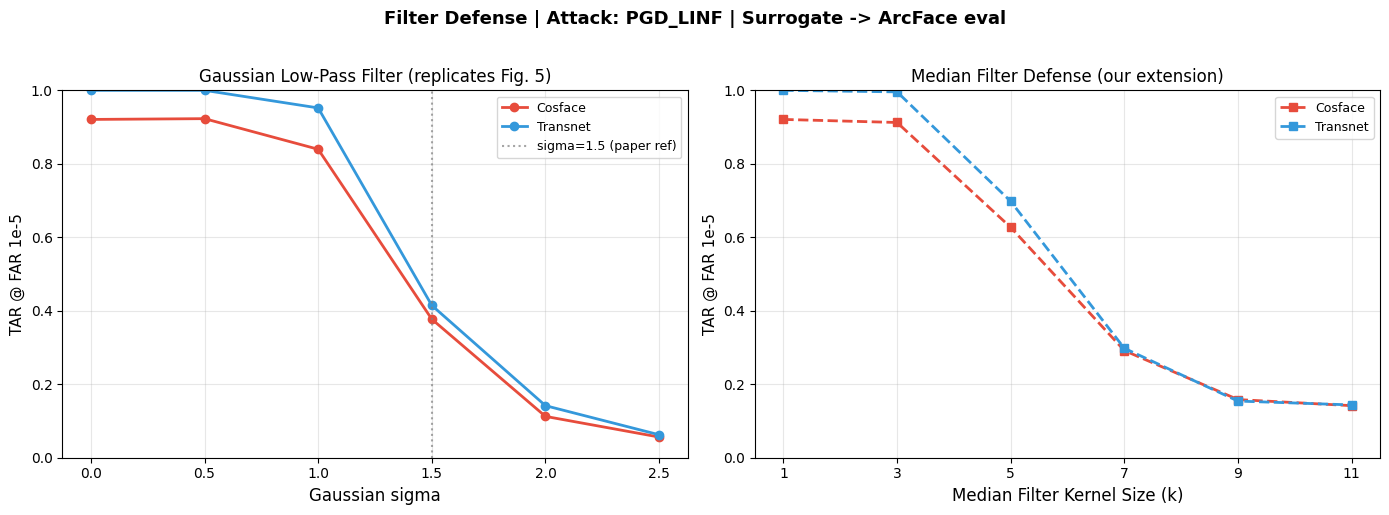


✅ Filter sweep saved to /teamspace/studios/this_studio/outputs/filter_sweep_comparison.png


In [15]:
# Cell 14 — Filter sweep: Gaussian sigma (replicates Figure 5) + Median extension
# Original issues:
#   - Swept kernel *size* instead of sigma (paper Fig 5 x-axis is sigma)
#   - max_batches=2 => ~64 images, very noisy
#   - Used kernel_results_gauss/median variable names (inconsistent with Cell 15)
# Fix:
#   - Gaussian: sigma in [0.0, 0.5, 1.0, 1.5, 2.0, 2.5] matching Figure 5
#   - Median: odd kernel sizes [1, 3, 5, 7, 9, 11] as our novel extension
#   - max_batches=15 for stable estimates
#   - Results stored in gauss_results / median_results for Cell 15

FAR_STRICT       = 1e-5
SIGMA_SURROGATES = ['cosface', 'transnet']
SIGMA_ATTACK     = 'pgd_linf'
MAX_BATCHES_FILT = 15

# Gaussian sigma values — matches paper Figure 5 x-axis
sigma_values = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5]

# Median odd kernel sizes (k=1 is identity / no filter)
median_kernel_sizes = [1, 3, 5, 7, 9, 11]


def sigma_to_ksize(sigma):
    if sigma == 0:
        return 1
    k = int(6 * sigma + 1)
    return k if k % 2 == 1 else k + 1  # must be odd


def make_gauss_defense_sigma(sigma):
    if sigma == 0.0:
        return None  # baseline: no filter
    k = sigma_to_ksize(sigma)
    return lambda x: kornia.filters.gaussian_blur2d(x, (k, k), (sigma, sigma))


def make_median_defense(k_size):
    if k_size <= 1:
        return None  # k=1 is identity
    return lambda x: kornia.filters.median_blur(x, (k_size, k_size))


# Storage dicts — referenced by Cell 15
gauss_results  = {sur: {} for sur in SIGMA_SURROGATES}
median_results = {sur: {} for sur in SIGMA_SURROGATES}

print(f'Filter sweep | attack={SIGMA_ATTACK} | FAR={FAR_STRICT:.0e} | batches={MAX_BATCHES_FILT}')
print(f'Gaussian sigma values : {sigma_values}')
print(f'Median kernel sizes   : {median_kernel_sizes}\n')

for surrogate in tqdm(SIGMA_SURROGATES, desc='Surrogate'):

    for sigma in tqdm(sigma_values, desc=f'  Gaussian sigma ({surrogate})', leave=False):
        defense = make_gauss_defense_sigma(sigma)
        tar = measure_leakage(
            ATTACKS[SIGMA_ATTACK], encoders[surrogate], encoders['arcface'], fiva,
            ff_loader, FAR_THRESHOLDS, defense=defense, max_batches=MAX_BATCHES_FILT,
        )
        gauss_results[surrogate][sigma] = round(tar[FAR_STRICT], 4)

    for k in tqdm(median_kernel_sizes, desc=f'  Median k ({surrogate})', leave=False):
        defense = make_median_defense(k)
        tar = measure_leakage(
            ATTACKS[SIGMA_ATTACK], encoders[surrogate], encoders['arcface'], fiva,
            ff_loader, FAR_THRESHOLDS, defense=defense, max_batches=MAX_BATCHES_FILT,
        )
        median_results[surrogate][k] = round(tar[FAR_STRICT], 4)

# Print summary tables
print('\n--- Gaussian sigma sweep (TAR @ FAR 1e-5) ---')
gauss_df = pd.DataFrame(gauss_results, index=sigma_values)
gauss_df.index.name = 'sigma'
print(gauss_df.to_string())

print('\n--- Median kernel sweep (TAR @ FAR 1e-5) ---')
median_df = pd.DataFrame(median_results, index=median_kernel_sizes)
median_df.index.name = 'kernel_size'
print(median_df.to_string())

# Plot: two side-by-side panels
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c', '#3498db']

# Left panel: Gaussian sigma (replicates paper Figure 5)
ax1 = axes[0]
for sur, color in zip(SIGMA_SURROGATES, colors):
    y = [gauss_results[sur][s] for s in sigma_values]
    ax1.plot(sigma_values, y, '-o', color=color, lw=2, markersize=6, label=sur.capitalize())
ax1.axvline(x=1.5, color='gray', linestyle=':', alpha=0.7, label='sigma=1.5 (paper ref)')
ax1.set_xlabel('Gaussian sigma', fontsize=12)
ax1.set_ylabel('TAR @ FAR 1e-5', fontsize=11)
ax1.set_title('Gaussian Low-Pass Filter (replicates Fig. 5)', fontsize=12)
ax1.set_ylim(0, 1)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Right panel: Median filter (our novel extension)
ax2 = axes[1]
for sur, color in zip(SIGMA_SURROGATES, colors):
    y = [median_results[sur][k] for k in median_kernel_sizes]
    ax2.plot(median_kernel_sizes, y, '--s', color=color, lw=2, markersize=6, label=sur.capitalize())
ax2.set_xlabel('Median Filter Kernel Size (k)', fontsize=12)
ax2.set_ylabel('TAR @ FAR 1e-5', fontsize=11)
ax2.set_title('Median Filter Defense (our extension)', fontsize=12)
ax2.set_xticks(median_kernel_sizes)
ax2.set_ylim(0, 1)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle(
    f'Filter Defense | Attack: {SIGMA_ATTACK.upper()} | Surrogate -> ArcFace eval',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
out_path = f'{OUT_DIR}/filter_sweep_comparison.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'\n✅ Filter sweep saved to {out_path}')


  Using column: arcface@FAR1e-05


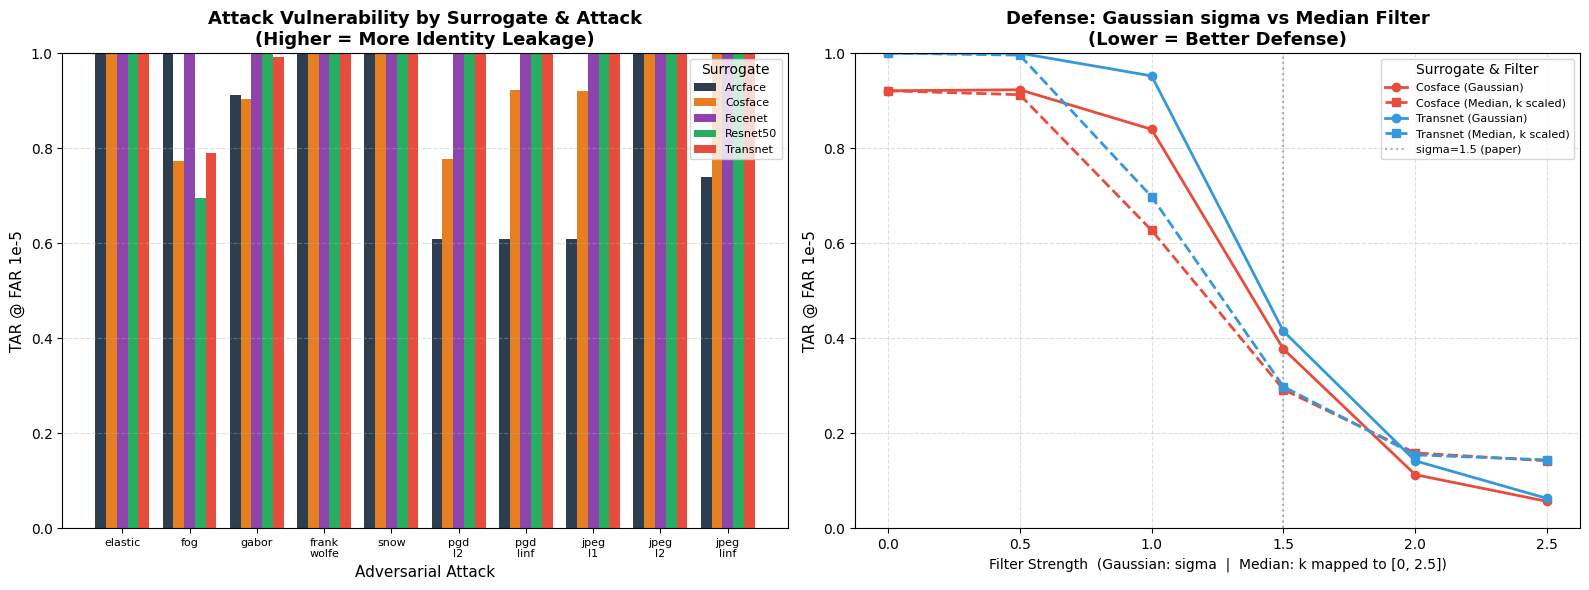

✅ Dashboard saved to /teamspace/studios/this_studio/outputs/comprehensive_analysis_dashboard_.png


In [16]:
# Cell 15 — Comprehensive Dashboard (Fixed)
# Bugs fixed:
#   - Column name 'arcface@FAR1e-5' corrected to 'arcface@FAR1e-05'
#   - Filter plot now reads from gauss_results/median_results (new Cell 14 vars)
#   - Gaussian x-axis is sigma (not kernel size)
#   - All surrogates shown in attack bar chart (not just 3)

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Attack Vulnerability by Surrogate ─────────────────────────────
try:
    ax1 = axes[0]
    surrogates  = list(df_II['surrogate'].unique())
    attack_list = list(df_II['attack'].unique())

    # Robustly find the correct arcface FAR 1e-5 column
    far_col = None
    for candidate in ['arcface@FAR1e-05', 'arcface@FAR1e-5']:
        if candidate in df_II.columns:
            far_col = candidate
            break
    if far_col is None:
        far_col = [c for c in df_II.columns if c.startswith('arcface')][0]
    print(f'  Using column: {far_col}')

    width  = 0.8 / max(len(surrogates), 1)
    colors = ['#2c3e50', '#e67e22', '#8e44ad', '#27ae60', '#e74c3c']
    x      = np.arange(len(attack_list))

    for i, sur in enumerate(surrogates):
        sub = df_II[df_II['surrogate'] == sur].set_index('attack')
        y   = [float(sub.loc[atk, far_col]) if atk in sub.index else 0.0
               for atk in attack_list]
        offset = (i - len(surrogates) / 2 + 0.5) * width
        ax1.bar(x + offset, y, width, label=sur.capitalize(),
                color=colors[i % len(colors)])

    ax1.set_title('Attack Vulnerability by Surrogate & Attack\n'
                  '(Higher = More Identity Leakage)', fontsize=13, fontweight='bold')
    ax1.set_ylabel('TAR @ FAR 1e-5', fontsize=11)
    ax1.set_xlabel('Adversarial Attack', fontsize=11)
    ax1.set_xticks(x)
    ax1.set_xticklabels([a.replace('_', '\n') for a in attack_list], fontsize=8)
    ax1.legend(title='Surrogate', fontsize=8)
    ax1.set_ylim(0, 1)
    ax1.grid(axis='y', linestyle='--', alpha=0.4)

except Exception as e:
    axes[0].text(0.5, 0.5, f'Plot 1 error:\n{e}', transform=axes[0].transAxes,
                 ha='center', va='center', color='red', fontsize=10)
    print(f'Plot 1 error: {e}')

# ── Plot 2: Filter Sweep (Gaussian sigma + Median kernel) ─────────────────
try:
    ax2 = axes[1]
    line_colors = ['#e74c3c', '#3498db']

    for idx, sur in enumerate(SIGMA_SURROGATES):
        c = line_colors[idx % len(line_colors)]

        # Gaussian: x-axis = sigma values
        y_g = [gauss_results[sur][s] for s in sigma_values]
        ax2.plot(sigma_values, y_g, '-o', color=c, lw=2, markersize=6,
                 label=f'{sur.capitalize()} (Gaussian)')

        # Median: map odd kernel sizes [1..11] onto [0..2.5] for shared x-axis
        med_x = [((k - 1) / 10.0) * 2.5 for k in median_kernel_sizes]
        y_m   = [median_results[sur][k] for k in median_kernel_sizes]
        ax2.plot(med_x, y_m, '--s', color=c, lw=2, markersize=6,
                 label=f'{sur.capitalize()} (Median, k scaled)')

    ax2.axvline(x=1.5, color='gray', linestyle=':', alpha=0.6, label='sigma=1.5 (paper)')
    ax2.set_title('Defense: Gaussian sigma vs Median Filter\n'
                  '(Lower = Better Defense)', fontsize=13, fontweight='bold')
    ax2.set_ylabel('TAR @ FAR 1e-5', fontsize=11)
    ax2.set_xlabel('Filter Strength  '
                   '(Gaussian: sigma  |  Median: k mapped to [0, 2.5])', fontsize=10)
    ax2.set_ylim(0, 1)
    ax2.legend(title='Surrogate & Filter', fontsize=8)
    ax2.grid(linestyle='--', alpha=0.4)

except Exception as e:
    axes[1].text(0.5, 0.5, f'Plot 2 error:\n{e}', transform=axes[1].transAxes,
                 ha='center', va='center', color='red', fontsize=10)
    print(f'Plot 2 error: {e}')

plt.tight_layout()
out_path = f'{OUT_DIR}/comprehensive_analysis_dashboard_.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ Dashboard saved to {out_path}')


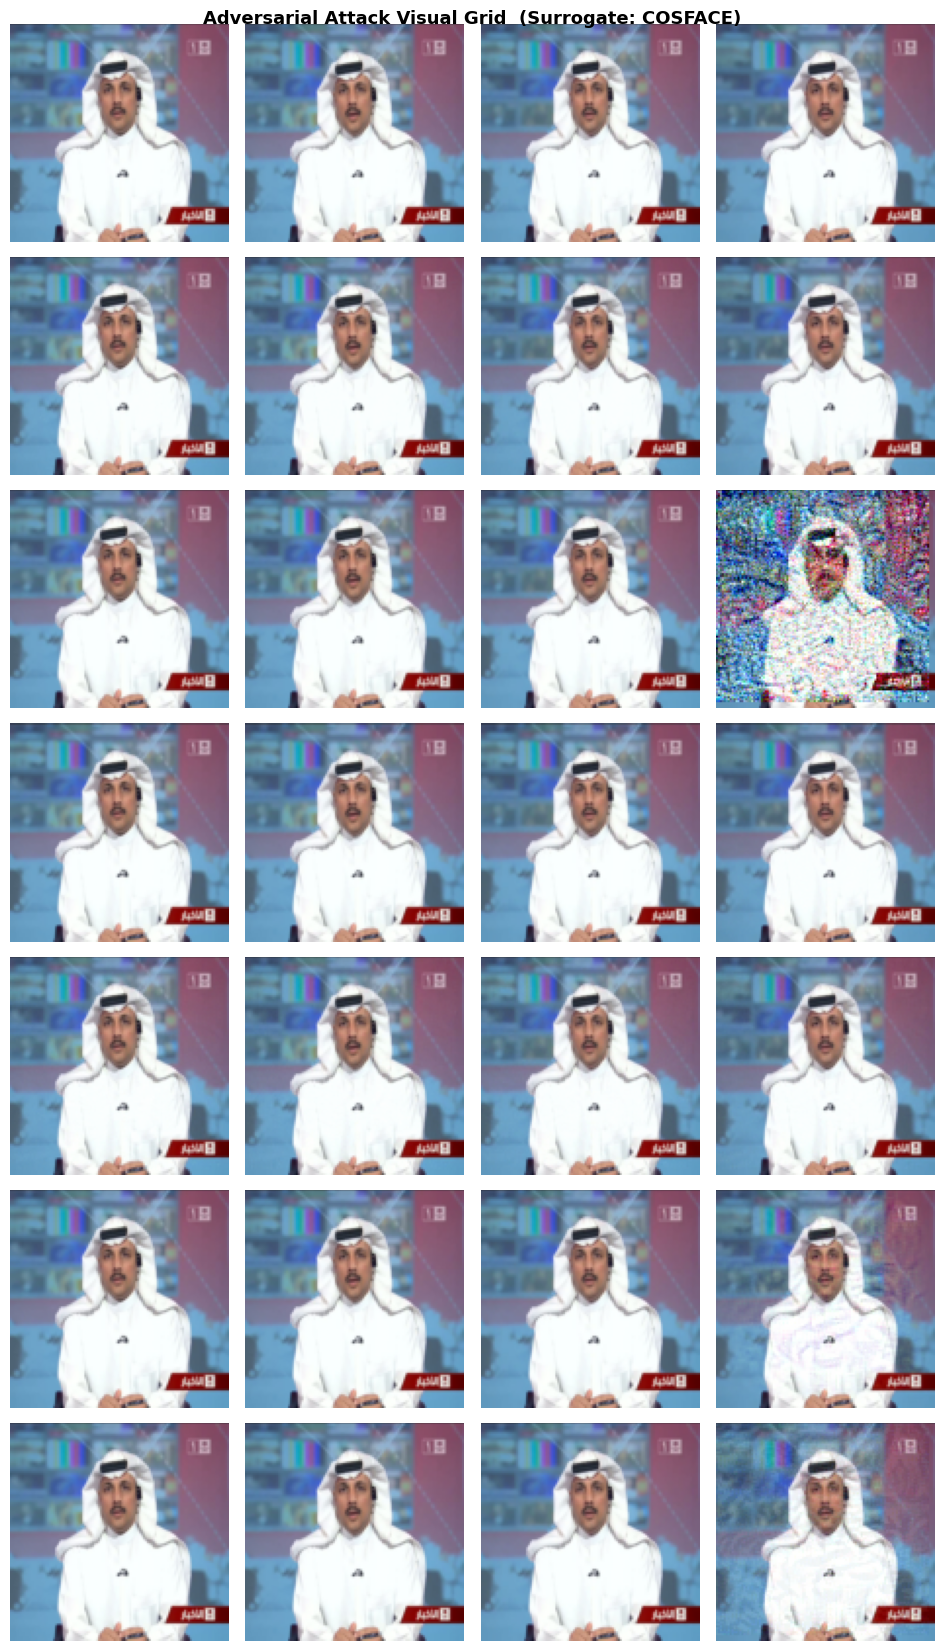

✅ Attack grid saved to /teamspace/studios/this_studio/outputs/attack_visual_grid.png

Building similarity distributions...


RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

In [17]:
# Cell 16 — Visualisation: attack image grid + similarity distributions

@torch.no_grad()
def denorm(t):
    return ((t.clamp(-1, 1) + 1) / 2).cpu()

VIS_ATTACKS   = ['elastic', 'fog', 'snow', 'frank_wolfe', 'pgd_l2', 'pgd_linf']
VIS_SURROGATE = 'cosface'
VIS_N_IMGS    = 4

vis_imgs, _ = next(iter(ff_loader))
vis_imgs = vis_imgs[:VIS_N_IMGS].to(device)

# ── Figure 1: Attack visual grid ─────────────────────────────────────────────
row_labels = ['Clean'] + [a.replace('_', ' ').title() for a in VIS_ATTACKS]
all_rows   = [[denorm(vis_imgs[j]) for j in range(VIS_N_IMGS)]]

for atk_name in VIS_ATTACKS:
    with torch.enable_grad():
        xadv = ATTACKS[atk_name](vis_imgs, encoders[VIS_SURROGATE])
    all_rows.append([denorm(xadv[j]) for j in range(VIS_N_IMGS)])

fig1, axes = plt.subplots(len(all_rows), VIS_N_IMGS,
                           figsize=(VIS_N_IMGS * 2.4, len(all_rows) * 2.4))
for r, (row_imgs, label) in enumerate(zip(all_rows, row_labels)):
    for c, img_t in enumerate(row_imgs):
        ax = axes[r, c]
        ax.imshow(img_t.permute(1, 2, 0).numpy().clip(0, 1))
        ax.axis('off')
        if c == 0:
            ax.set_ylabel(label, fontsize=9, rotation=0,
                          labelpad=60, va='center', fontweight='bold')

plt.suptitle(f'Adversarial Attack Visual Grid  (Surrogate: {VIS_SURROGATE.upper()})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
out1 = f'{OUT_DIR}/attack_visual_grid.png'
plt.savefig(out1, dpi=200, bbox_inches='tight')
plt.show()
print(f'✅ Attack grid saved to {out1}')


# ── Figure 2: Cosine similarity distributions ────────────────────────────────
# Shows impostor | clean | adversarial distributions relative to FAR thresholds.
# Mass of adversarial curve RIGHT of threshold = identity leakage.

print('\nBuilding similarity distributions...')

all_embs = []
for i, (imgs, _) in enumerate(ff_loader):
    if i >= 10: break
    all_embs.append(encoders['arcface'](imgs.to(device)).float().cpu())
all_embs = torch.cat(all_embs, 0)
N = all_embs.shape[0]

# Clean adjacent-pair sims (rough "same-batch" reference)
clean_sims = F.cosine_similarity(all_embs[:-1], all_embs[1:], dim=1).numpy()
# Impostor: shift by N//2
imp_sims   = F.cosine_similarity(
    all_embs, all_embs[(torch.arange(N) + N // 2) % N], dim=1).numpy()

# Adversarial sims for three surrogates using pgd_linf
adv_sims = {}
for sur in ['arcface', 'cosface', 'transnet']:
    sims_list = []
    for i, (imgs, _) in enumerate(ff_loader):
        if i >= 10: break
        imgs = imgs.to(device)
        with torch.enable_grad():
            xadv = ATTACKS['pgd_linf'](imgs, encoders[sur])
        with torch.no_grad():
            z0 = encoders['arcface'](imgs).float().cpu()
            za = encoders['arcface'](xadv).float().cpu()
        sims_list.append(F.cosine_similarity(z0, za, dim=1))
    adv_sims[sur] = torch.cat(sims_list, 0).numpy()

fig2, ax = plt.subplots(figsize=(11, 5))
ax.hist(imp_sims,   bins=80, alpha=0.45, color='steelblue',
        label='Impostor (different people)',   density=True)
ax.hist(clean_sims, bins=80, alpha=0.45, color='limegreen',
        label='Clean (same image, no attack)', density=True)

adv_colors = ['#e74c3c', '#e67e22', '#9b59b6']
for (sur, sims), col in zip(adv_sims.items(), adv_colors):
    ax.hist(sims, bins=80, alpha=0.5, color=col, density=True,
            label=f'PGD-inf (surrogate={sur})')

for far, thr in FAR_THRESHOLDS.items():
    ax.axvline(thr, color='black', linestyle='--', linewidth=1.2,
               label=f'FAR {far:.0e} thr={thr:.3f}')

ax.set_xlabel('Cosine Similarity (ArcFace eval)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Similarity Distributions: Impostor vs Clean vs Adversarial\n'
             'Adversarial mass right of dashed threshold = identity leakage',
             fontsize=12)
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
out2 = f'{OUT_DIR}/similarity_distributions.png'
plt.savefig(out2, dpi=200, bbox_inches='tight')
plt.show()
print(f'✅ Similarity distributions saved to {out2}')


# ── Figure 3: Per-attack leakage bar chart (from Table II df_II) ─────────────
try:
    fig3, axes3 = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    far_labels = [f'FAR {f:.0e}' for f in CFG['far_values']]
    colors     = ['#2c3e50', '#e67e22', '#8e44ad', '#27ae60', '#e74c3c']
    surrogates = list(df_II['surrogate'].unique())
    attack_list= list(df_II['attack'].unique())
    x          = np.arange(len(attack_list))
    width      = 0.8 / max(len(surrogates), 1)

    for ax_i, (ax3, far) in enumerate(zip(axes3, CFG['far_values'])):
        col = f'arcface@FAR{far:.0e}'
        for j, sur in enumerate(surrogates):
            sub  = df_II[df_II['surrogate'] == sur].set_index('attack')
            yvals= [float(sub.loc[a, col]) if a in sub.index else 0.0
                    for a in attack_list]
            offset = (j - len(surrogates) / 2 + 0.5) * width
            ax3.bar(x + offset, yvals, width,
                    label=sur.capitalize(), color=colors[j % len(colors)])
        ax3.set_title(f'ArcFace eval @ {far_labels[ax_i]}', fontsize=11)
        ax3.set_xticks(x)
        ax3.set_xticklabels([a.replace('_', '\n') for a in attack_list], fontsize=7)
        ax3.set_ylim(0, 1)
        ax3.grid(axis='y', alpha=0.3)
        if ax_i == 0:
            ax3.set_ylabel('TAR (identity leakage)', fontsize=11)
            ax3.legend(title='Surrogate', fontsize=7)

    plt.suptitle('Table II — Identity Leakage per Attack & Surrogate (ArcFace eval)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    out3 = f'{OUT_DIR}/table_II_bar_chart.png'
    plt.savefig(out3, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'✅ Table II bar chart saved to {out3}')
except Exception as e:
    print(f'Table II chart skipped (run Cell 13 first): {e}')